# Complex numbers

In [89]:
imag = 1j
print(imag ** 2)

complex_num = 3+2j
print(complex_num * imag)
print(abs(complex_num))

(-1+0j)
(-2+3j)
3.605551275463989


In [90]:
import numpy as np

complex_vec = np.array([imag,complex_num])
print(complex_vec)
print(complex_vec.real)
print(complex_vec.imag)
print(np.abs(complex_vec))
print(complex_vec.dtype)

[0.+1.j 3.+2.j]
[0. 3.]
[1. 2.]
[1.         3.60555128]
complex128


# Fourier Transform

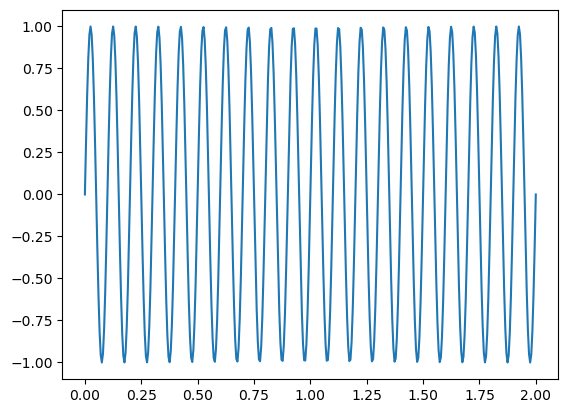

In [91]:
from numpy import fft
import matplotlib.pyplot as plt
num_samples = 400
samples_freq = 1/200
times = np.linspace(0,samples_freq * num_samples,num_samples)
# create one signal
simple_signal = np.sin(20 * np.pi * times)
plt.plot(times, simple_signal)

## rfft & rfftfreq

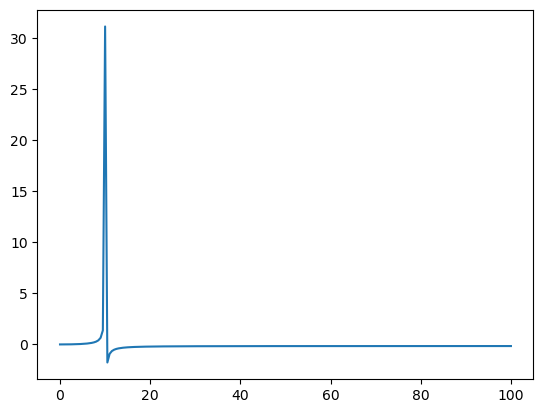

In [92]:
#fft
F_f = fft.rfft(simple_signal)
frq_domain = fft.rfftfreq(num_samples,samples_freq)
plt.plot(frq_domain,F_f.real)
#plt.plot(frq_domain,F_f.imag)

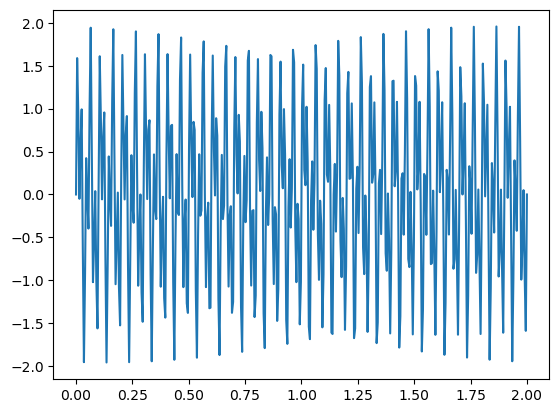

In [93]:
#create two signal
two_signals = np.sin(100 * np.pi * times) + np.sin(40 * np.pi * times)
plt.plot(times, two_signals)

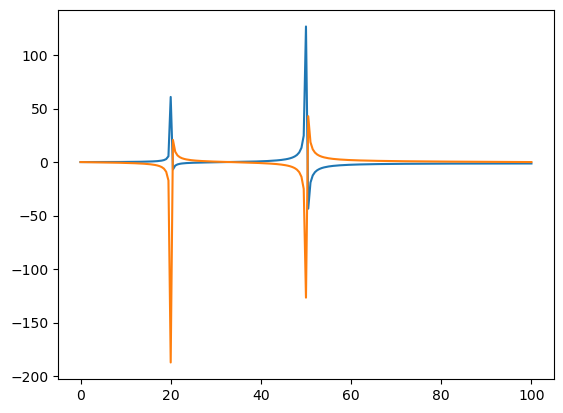

In [94]:
F_f2 = fft.rfft(two_signals)
plt.plot(frq_domain,F_f2.real)
plt.plot(frq_domain,F_f2.imag)

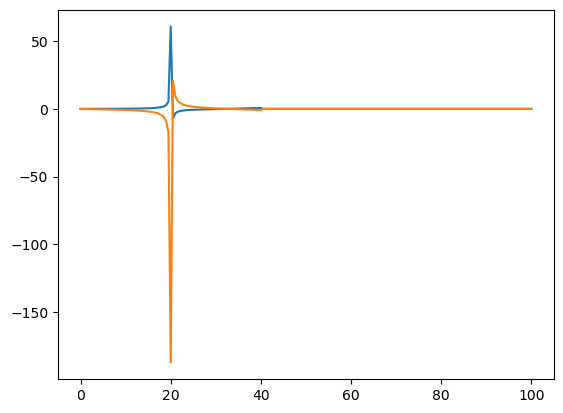

In [95]:
# filter one signal
F_f2[frq_domain>40] = 0
plt.plot(frq_domain,F_f2.real)
plt.plot(frq_domain,F_f2.imag)

## inverse: irfft

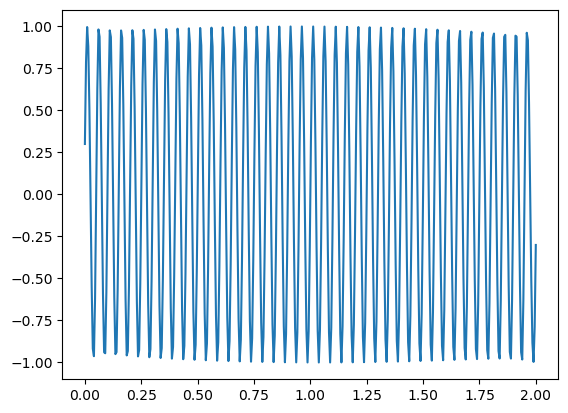

In [96]:
# inverse fft to signal
low_frq = fft.irfft(F_f2)
plt.plot(times,low_frq)

# smooth a signal

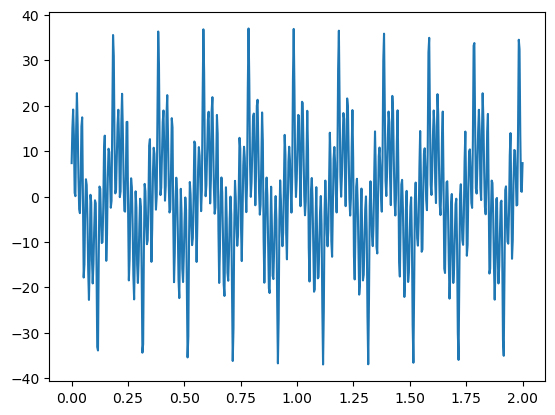

In [97]:
times = np.linspace(0,2,600)
signal = 20 * np.exp(-np.cos(30 * np.pi * times) ** 2) * (np.cos(10 * np.pi * times) + np.sin(100 * np.pi * times))
plt.plot(times,signal)

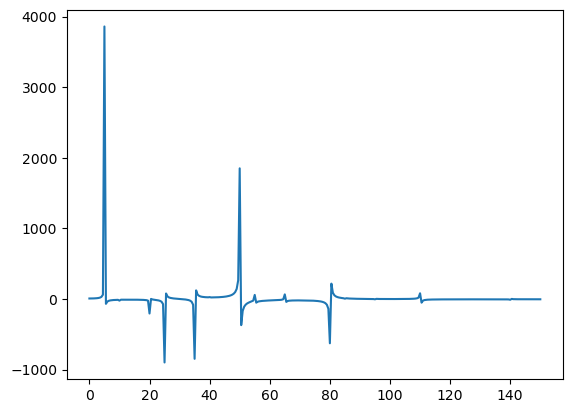

In [98]:
f_3 = fft.rfft(signal)
frq_domain_3 =fft.rfftfreq(600,2/600)
plt.plot(frq_domain_3,f_3.real)

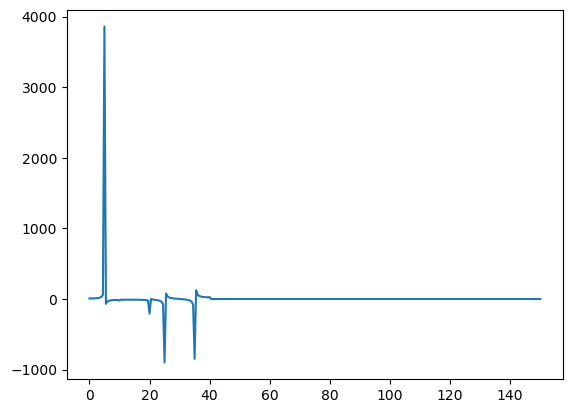

In [99]:
f_3[frq_domain_3>40] =0
plt.plot(frq_domain_3,f_3.real)

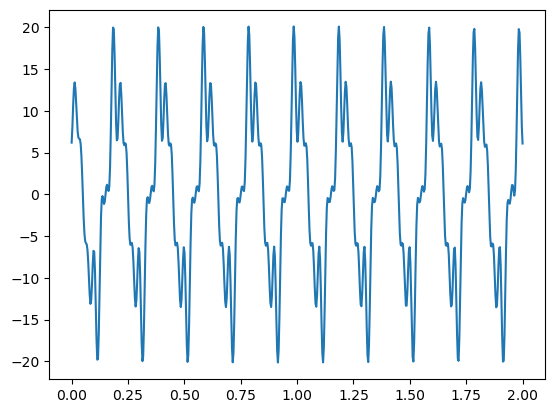

In [100]:
#smooth
smooth = fft.irfft(f_3)
plt.plot(times,smooth)

# 2D Fourier Transform - compression photo

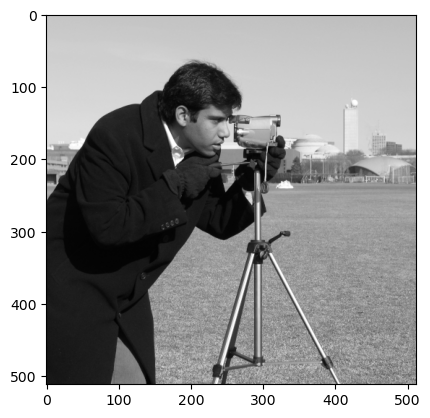

In [101]:
from skimage.data import camera
camera = camera()
plt.imshow(camera,cmap = plt.cm.gray)

131584


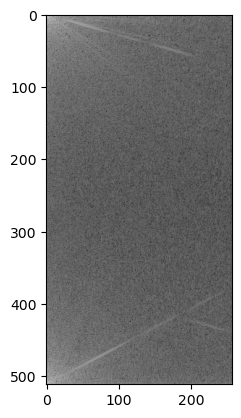

In [102]:
F_camera = fft.rfft2(camera)
log = np.log(1+np.abs(F_camera))/np.log(1+np.abs(F_camera).max())
print(np.count_nonzero(F_camera))
plt.imshow(log,cmap=plt.cm.gray)

3456


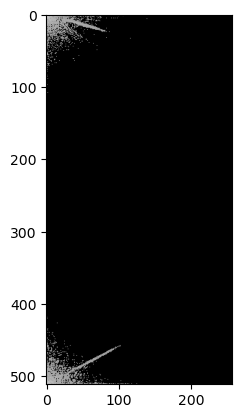

In [ ]:
F_camera[np.abs(F_camera)<30000] = 0
print(np.count_nonzero(F_camera))
log = np.log(1+np.abs(F_camera))/np.log(1+np.abs(F_camera).max()) #Log compression and Normalization
plt.imshow(log,cmap=plt.cm.gray)

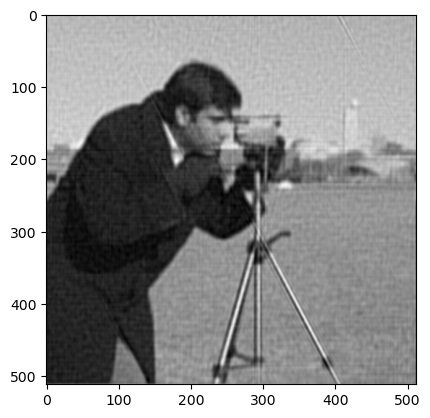

In [104]:
compressed = fft.irfft2(F_camera)
plt.imshow(compressed,cmap = plt.cm.gray)

# play audio

In [108]:
import IPython
sampling_rate = 22050
g_chord = np.load("g_chord.npy")
#e_tone = np.load("e_tone.npy")
IPython.display.Audio(g_chord, rate=sampling_rate)
#IPython.display.Audio(e_tone, rate=sampling_rate)